## Tools Setup

In [2]:
import pathlib, os, sys, operator, re, datetime
from functools import reduce
import numpy as np
import tensorflow as tf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import Model
import tensorflow_datasets as tfds # 
from tiny_imagenet import TinyImagenetDataset #this is used for downloading subset of selected images from the 14 million total images
import math
from prettytable import PrettyTable
from matplotlib import pyplot
import seaborn as sns
import time


# Enable or disable GPU
# To fully disable it, we need to hide all GPU devices from Tensorflow
# Make sure GPU is disabled for this inference part of the lab
ENABLE_GPU = True
# tf.debugging.set_log_device_placement(True)

if not ENABLE_GPU:
    tf.config.set_visible_devices([], 'GPU')

# Print Python and TF version, and where we are running
print(f'Running on Python Version: {sys.version}')
print(f'Using Tensorflow Version: {tf. __version__}')
if not tf.config.experimental.list_physical_devices("GPU"):
    print('Running on CPU')
else:
    print(f'Using GPU at: {tf.test.gpu_device_name()} (of {len(tf.config.experimental.list_physical_devices("GPU"))} available)')

Running on Python Version: 3.9.25 (main, Aug  6 2026, 00:00:00) 
[GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
Using Tensorflow Version: 2.16.2
Running on CPU


In [3]:
#Load the model
model_path = os.path.abspath("CNN_TinyImageNet.h5")

model = tf.keras.models.load_model(model_path)
model.summary()

/home/umhaihl/machine_learning/lab4/python_stuff/lab4_venv/lib64/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/umhaihl/machine_learning/lab4/python_stuff/lab4_venv/lib64/python3.9/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770,218 (2.94 MB)

 Trainable params: 770,216 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

-127
[-9, 3, 21, 39, 35, 14, -12, 32, -22, 15, -29, 2, 5, 46, -31, 27, 17, 34, -22, 7, -10, 6, 3, 29, -32, -23, 22, 4, -31, 4, -3, -9, -2, -38, 24, 40, 2, 13, 30, 4, 9, -17, 2, -32, 25, 4, -12, 21, 39, 0, -46, 2, -46, -14, 8, 4, -1, -16, -19, -11, 11, 32, -30, -19, -20, -28, 27, 22, 30, 2, 9, 29, -21, 16, 20, -28, 3, -14, -48, -17, 12, 38, -34, 22, -9, 41, 32, 9, -25, 36, 17, -17, 39, -29, -35, 35, 16, 29, 16, 40, 37, 7, -24, -2, 22, 12, -10, 30, 41, -13, -10, -1, 39, 33, 1, 27, -34, 10, -35, 19, -3, -32, 47, 2, -16, 17, -22, -31, 37, -12, -51, 34, -27, 22, 13, -67, 18, 38, -21, 5, 11, -22, -24, 39, 51, -3, -14, 18, -38, 42, -49, -38, -51, -13, -16, 20, -3, -32, -13, 27, 31, -31, -26, 4, 25, 47, -14, -111, 41, 50, 27, 25, 25, 16, 1, 25, 13, 27, -39, -19, -9, 38, -5, 19, -17, -8, 33, 32, -25, -21, -43, 6, 13, 22, 38, 15, -35, -6, -6, -43, 0, -47, -2, -22, 0, 7, -22, -56, 55, 8, -35, 48, -41, -56, -17, 21, -63, 20, -36, -6, 18, 37, -5, 27, 18, 12, 12, -26, 7, 13, 35, -23, -20, -4, 7, 18,

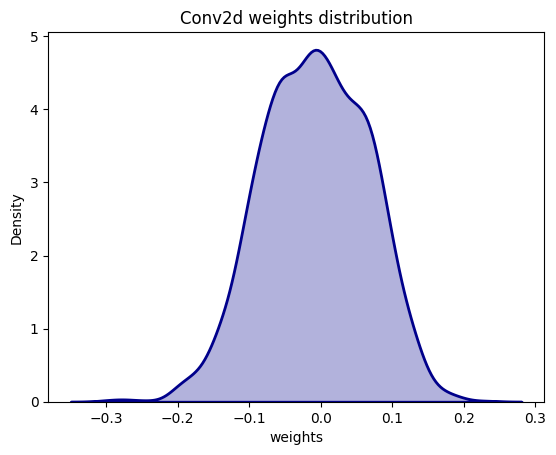

In [4]:
##############################  Weight Quantization  ###############################
#Export quantized weights
# Make a directory for our image data
model_dir = os.path.abspath('quantized_model_data')
pathlib.Path(model_dir).mkdir(exist_ok=True)

conv2d_layer_weights = model.layers[0].weights[0].numpy().flatten()
conv2d_layer_weights_shape = model.layers[0].weights[0].shape

#calculating the max and the min weights for conv2d layer
conv2d_min_w = conv2d_layer_weights.min()
conv2d_max_w = conv2d_layer_weights.max()

#find the scaling factor for layer1
conv2d_Sw = 127/max(abs(conv2d_min_w), abs(conv2d_max_w)) 

#construct quantized weights array for conv2d
conv2d_quantized_weights = []
for d_weight in conv2d_layer_weights:
    conv2d_quantized_weights.append(round(conv2d_Sw * d_weight))

#Just for checking, to see if quantized_weights is correct
print(np.min(conv2d_quantized_weights))
print(conv2d_quantized_weights)
print(np.array(conv2d_quantized_weights, dtype=np.int8).tobytes())

#create a file for quantized weights and put them in there 
quantized_weight_file_name = os.path.join(model_dir, f'conv2d_quantized_weights.bin')

with open(quantized_weight_file_name, 'wb') as f:
    f.write(np.array(conv2d_quantized_weights, dtype=np.int8).tobytes())

# reshaping so when doing bias quantization we get good stuff
conv2d_quantized_weights = np.array(conv2d_quantized_weights, dtype=np.int8).reshape(conv2d_layer_weights_shape)

#plotting the distrubution of weights for conv2d layer
sns.kdeplot(conv2d_layer_weights, color='darkblue', linewidth=2, fill=True, alpha=0.3)
plt.title("Conv2d weights distribution")
plt.xlabel("weights")
plt.show()

## Dataset Inspection

In [5]:
# This cell imports our dataset.

# Original Source: https://github.com/ksachdeva/tiny-imagenet-tfds
# Class Version Source: https://github.com/duweisu/tiny-imagenet-tfds
# Setup our dataset
# ---------------------------------------------------------

#so basically what this is: ImageNet is a massive amout of image data (over 14 million images) available, but since we don't want that much,
#we are just downloading a subset of them to train
tiny_imagenet_builder = TinyImagenetDataset() #make an instance of the class.

# this call (download_and_prepare) will trigger the download of the dataset
# and preparation (conversion to tfrecords)
#
# This will be done only once and on next usage tfds will
# use the cached version on your host.
tiny_imagenet_builder.download_and_prepare(download_dir="~/tensorflow-datasets/downloads")

# class_names = tiny_imagenet_builder.info.features['label'].names
ds = tiny_imagenet_builder.as_dataset() # convert all the downlaoded things to datasets
ds_train, ds_val = ds["train"], ds["validation"] # ds["train"] is the dataset of images that are used for training
                                                 # ds["validation"] is the dataset of images that are used for validation
assert(isinstance(ds_train, tf.data.Dataset)) # make sure both ds_train and tf.data.Dataset have the correct type.
assert(isinstance(ds_val, tf.data.Dataset))# make sure both ds_train and tf.data.Dataset have the correct type.

# Training Dataset
ds_train = ds_train.prefetch(tf.data.AUTOTUNE) #shuffle the training set in chunks of 1024

# Validation Dataset
ds_val = ds_val.prefetch(tf.data.AUTOTUNE) #shuffle the validation set in chunks of 1024

# Dataset metadata
ds_info = tiny_imagenet_builder.info

[0.27450982 0.14509805 0.07058824 ... 0.9490196  0.74509805 0.6       ]
0.32562488
188.32248822866472
-61


2026-10-04 13:17:27.616629: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


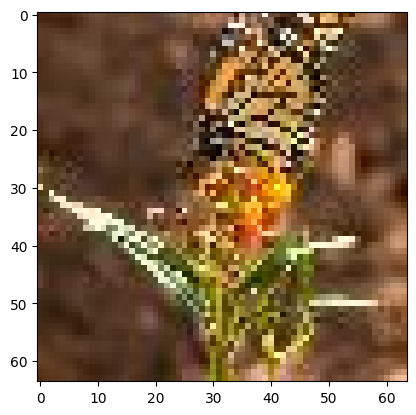

In [6]:
##############################  Input Quantization Parameteres  ###############################

#get the first picture of the train dataset and plot it to know we are doing good
img = next(iter(ds_train))

# convert the image array into fp32 to quantize it
image = img['image'].numpy().astype(np.float32) / 255.0

plt.figure()
plt.imshow(image)
# we could also recast it to uint8 first, but matplotlib supports both ways, so above line works fine as well
#plt.imshow(np.round(image * 255.0).astype(np.uint8))

# flatten the image so it is easier to work with
image_flatten = image.flatten()
print(image_flatten)

conv2d_max_i = image_flatten.max() #tested was 1
conv2d_min_i = image_flatten.min() #tested was 0
conv2d_avg_i = image_flatten.mean()
print(conv2d_avg_i)

# get the scale factor for a single input for conv2d layer
conv2d_Si = 127 / max(abs(conv2d_min_i - conv2d_avg_i), abs(conv2d_max_i - conv2d_avg_i))
print(conv2d_Si)

# compute the offset 
conv2d_Zi = -1 * round(conv2d_Si * conv2d_avg_i)
print(conv2d_Zi)

In [7]:
##############################  Bias Quantizations  ###############################
### THE SUM OF w_x IS ONLY THE SUM oF WEIGHTS OF ONE KERNEL AND NOT ALLLL!!!!

#Export quantized weights
# Make a directory for our image data

# flatten all the biases
conv2d_layer_biases = model.layers[0].weights[1].numpy().flatten()

# make a list to store the quantized biases
conv2d_quantized_biases = []
for d_bias in conv2d_layer_biases:
    conv2d_quantized_biases.append(round(conv2d_Si * conv2d_Sw * d_bias))

# from the equation in my iPad, get the effective bias, where we merge all the leftover terms with the bias
conv2d_quantized_combined_biases = []

for i, d_quatized_bias in enumerate(conv2d_quantized_biases):
    conv2d_quantized_combined_biases.append(d_quatized_bias - (conv2d_Zi * np.sum(conv2d_quantized_weights[:,:,:,i])))

print(conv2d_quantized_biases)


#create a file for quantized weights and put them in there 
quantized_biases_file_name = os.path.join(model_dir, f'conv2d_quantized_combined_biases.bin')

with open(quantized_biases_file_name, 'wb') as f:
    f.write(np.array(conv2d_quantized_combined_biases, dtype=np.int32).tobytes())

[654, 603, -582, 2377, 206, 3957, -2288, 2255, 3594, -3268, 1676, 806, 5348, 831, 2688, 1641, 2010, 93, -1800, -999, 988, -2323, 2069, 410, -639, 233, -1, -1031, 2234, 7708, -374, -4522]


In [8]:
########################## Import the Scaling Fators #########################
#Ah just write them as .txt for now. C++ should be reading and importing these. For now I use #define in C++

scaling_factors_text =  [
    f"conv2d_Sw : {conv2d_Sw}",
    f"conv2d_Si : {conv2d_Si}",
    f"conv2d_Zi : {conv2d_Zi}"
]

scaling_factors_info_file_name = os.path.join(model_dir, f'scaling_factors_info.txt')

with open(scaling_factors_info_file_name, "w", encoding="utf-8") as f:
    f.write("\n".join(scaling_factors_text))

In [9]:
########################## Import the Test Image #########################
# Not needed, but I just wanted to verify that my imports are fine by using them with lab2 code.

# make a new directory for input_image and intermediate feature maps
input_dir = os.path.abspath('test_input')
pathlib.Path(input_dir).mkdir(exist_ok=True)


test_input_image_file_name = os.path.join(input_dir, f'test_input_image.bin')

with open(test_input_image_file_name, 'wb') as f:
    f.write(image_flatten.tobytes())

In [10]:
######################## Import the intermediate feature maps ####################
## Doin this so we can compare our intermedaite feature maps. 

# make a new directory for intermediate feature maps
feature_maps_dir = os.path.abspath('test_input_feature_maps')
pathlib.Path(feature_maps_dir).mkdir(exist_ok=True)

#create a placeholder tensor
inp = tf.keras.Input(shape=(64, 64, 3))
x = inp             
outs = []     # array to hold all the intermediate output tensor

#model.layers is a list of Layer objects
#it is also callable as self funciton.
for layer in model.layers: #we want the intermediate results only so don't get the last layer which is flat
    x = layer(x)   #so when you call layer() it takes an input tensor and returns the output tensor
                   # which then we feed into the next layer
    outs.append(x) # we append each output to an array so we can see how our intermediate feature maps look like

feature_map_model = tf.keras.Model(inputs=inp, outputs=outs) #create a model. A clone of the loaded model but we can access intermediate feature maps

layer_names = [l.name for l in feature_map_model.layers]

batched_image = tf.expand_dims(image, axis=0)

pred = feature_map_model.predict(batched_image)

pred_layer_named_outs = dict(zip(layer_names[1:], pred)) # NOTE this is how to make a dict when one has names and the other values. zip them

for key, value in pred_layer_named_outs.items(): # NOTE had to put .items() since I am iterating over the itmes

    print(key)

    feaure_file_name = os.path.join(feature_maps_dir, f'{key}_feature.bin')

    with open(feaure_file_name, 'wb') as f:
        f.write(value.flatten().tobytes())

#making sure layer_names have the same length as output features
assert len(layer_names[1:]) == len(pred) 


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
conv2d
conv2d_1
max_pooling2d
conv2d_2
conv2d_3
max_pooling2d_1
conv2d_4
conv2d_5
max_pooling2d_2
flatten
dense
dense_1


In [11]:
######################## Import Quantized input test Image ####################
# This later has to be done in C++. Doing it here just to make C++ cleaner to begin with

def clamp(n, min_val, max_val):
    return max(min(n, max_val), min_val)

quantized_input = []
for image_float_val in image_flatten:
    temp = round((conv2d_Si * image_float_val) + conv2d_Zi)
    quantized_input.append(clamp(temp, -128, 127))

print(quantized_input)

quantized_test_input_file_name = os.path.join(input_dir, f'quantized_test_input_image.bin')

with open(quantized_test_input_file_name, 'wb') as f:
    f.write(np.array(quantized_input, dtype=np.int8).tobytes())

[-9, -34, -48, -9, -33, -47, -6, -31, -45, -4, -29, -43, -6, -30, -44, -6, -31, -45, -2, -26, -40, 5, -20, -34, 11, -13, -27, 18, -6, -20, 22, -3, -17, 18, -6, -20, 13, -12, -26, 11, -13, -27, 13, -12, -26, 14, -10, -26, 18, -7, -27, 14, -9, -29, 13, -12, -26, 11, -11, -23, 11, -12, -19, 12, -9, -17, 19, 0, -9, 30, 10, -3, 35, 14, -1, 42, 19, -1, 34, 7, -14, 41, 11, -14, 51, 15, -9, 73, 34, 10, 59, 17, -4, 69, 28, 8, 55, 17, -1, 47, 13, -4, -9, -43, -58, 95, 65, 51, 21, -6, -20, 51, 26, 14, 33, 8, -4, 127, 119, 106, 15, -8, -23, 18, -5, -20, -2, -23, -38, -4, -24, -38, -17, -34, -47, 116, 101, 90, 109, 97, 86, 5, -13, -34, 12, -18, -58, 98, 60, 11, 113, 76, 28, 86, 49, 4, 1, -35, -61, 25, -12, -50, -3, -38, -61, 62, 27, -4, 65, 29, 3, 70, 36, 11, 75, 42, 19, 70, 36, 15, 53, 20, 0, 31, -1, -21, 12, -19, -37, 3, -28, -46, -9, -33, -47, -10, -34, -48, -10, -34, -48, -10, -34, -48, -12, -37, -51, -13, -37, -51, -8, -32, -46, -1, -26, -40, 7, -17, -31, 14, -11, -25, 17, -7, -21, 15, -9, -23

## Dawud's Lab 4:

conv2d: 
  min = -0.30288, max = 0.23425


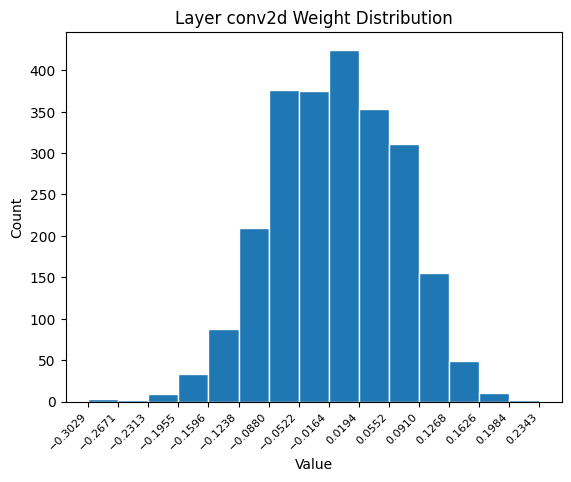

conv2d_1: 
  min = -0.48678, max = 0.38255


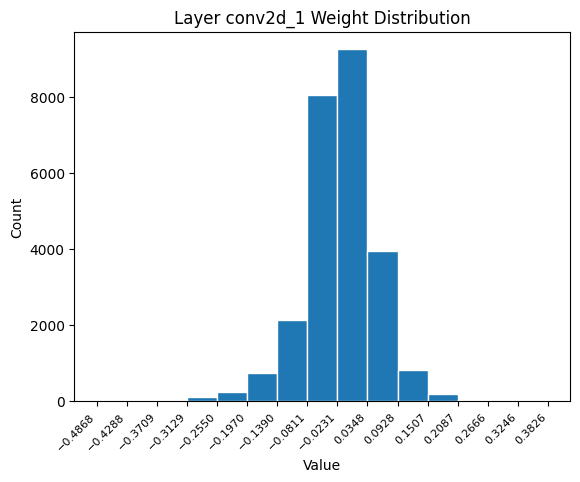

conv2d_2: 
  min = -0.69238, max = 0.32483


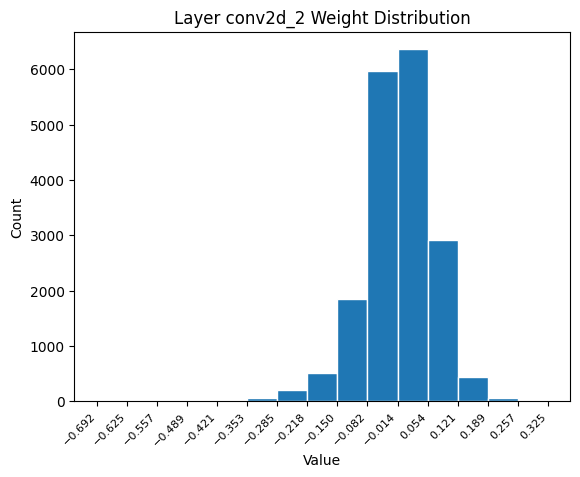

conv2d_3: 
  min = -0.54155, max = 0.36291


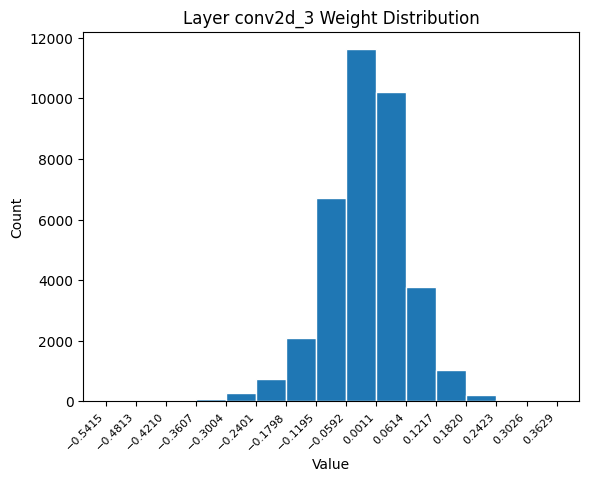

conv2d_4: 
  min = -0.53668, max = 0.36240


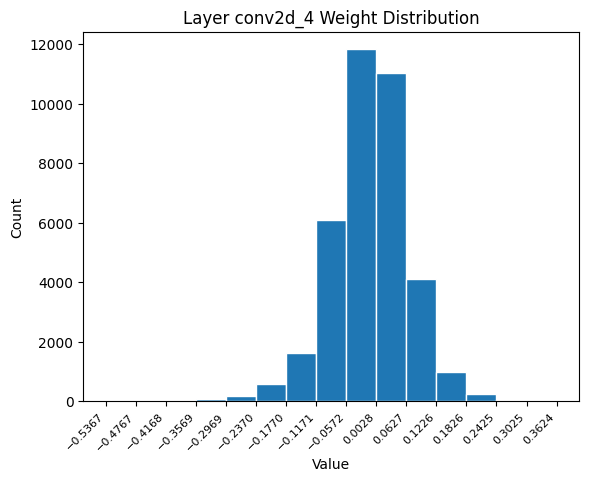

conv2d_5: 
  min = -0.51066, max = 0.46819


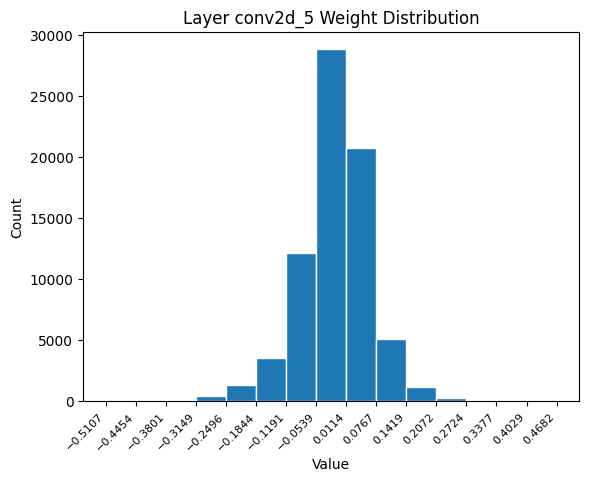

dense: 
  min = -0.55759, max = 0.51280


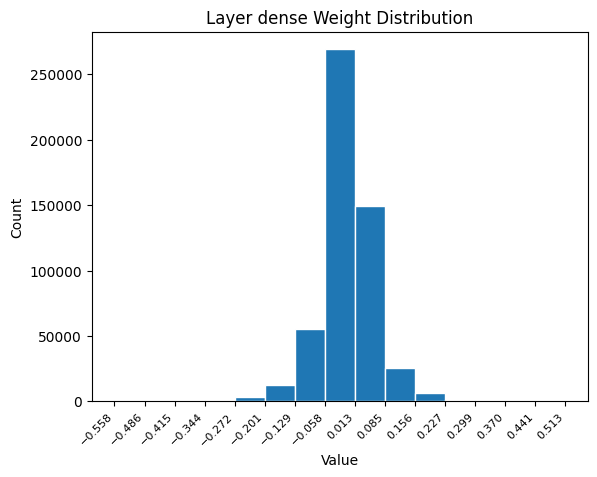

dense_1: 
  min = -1.32412, max = 0.36657


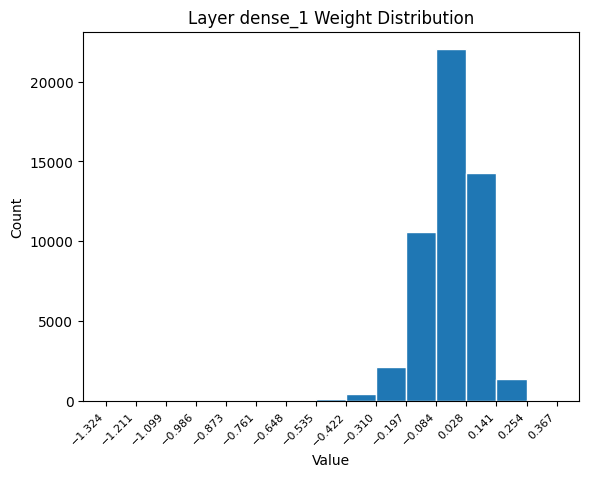

In [12]:
# Plot weights and find each layers min/max

weights_min = {}
weights_max = {}
weights_mag = {}

for layer_idx, layer in enumerate(model.layers):
    if re.match(r'(conv|dense)', layer.name):
        weights_flatten = layer.weights[0].numpy().flatten()
        
        weights_min[layer.name] = weights_flatten.min()
        weights_max[layer.name] = weights_flatten.max()
        weights_mag[layer.name] = max(abs(weights_max[layer.name]), abs(weights_min[layer.name]))

        print(f"{layer.name}: \n  min = {weights_min[layer.name]:.5f}, max = {weights_max[layer.name]:.5f}")
        
        _, bins, _ = plt.hist(weights_flatten, bins=15, edgecolor='w')
        plt.ylabel("Count")
        plt.xlabel("Value")
        plt.title(f"Layer {layer.name} Weight Distribution")
        plt.xticks(bins, rotation=45, ha="right", fontsize=8)
        plt.show()

In [13]:
# Find the activation min/max

model = tf.keras.models.load_model("CNN_TinyImageNet.h5")

fm_outputs = []
fm_layers = []

for layer in model.layers:
    fm_layers.append(layer)
    fm_outputs.append(layer.output)

fm_model = tf.keras.Model(inputs=model.inputs, outputs=fm_outputs)

activation_min = {layer.name: np.inf for layer in fm_layers}
activation_max = {layer.name: -np.inf for layer in fm_layers}
activation_sum = {layer.name: 0.0 for layer in fm_layers}
activation_count = {layer.name: 0 for layer in fm_layers}

input_min = np.inf
input_max = -np.inf
input_sum = 0.0

num_imgs = 1000
for img in ds_train.batch(1).take(num_imgs):

    norm_img = tf.cast(img['image'], tf.float32) / 255.0

    image_avg = tf.reduce_mean(norm_img).numpy()
    input_sum += image_avg

    input_min = min(input_min, tf.reduce_min(norm_img).numpy())
    input_max = max(input_max, tf.reduce_max(norm_img).numpy())

    activations = fm_model(norm_img, training=False)

    if len(fm_layers) == 1:
        activations = [activations]

    for layer, activation in zip(fm_layers, activations):
        
        cur_min = tf.reduce_min(activation).numpy()
        cur_max = tf.reduce_max(activation).numpy()

        activation_min[layer.name] = min(activation_min[layer.name], cur_min)
        activation_max[layer.name] = max(activation_max[layer.name], cur_max)

        activation_sum[layer.name] += tf.reduce_sum(activation).numpy()
        activation_count[layer.name] += tf.size(activation).numpy()

print(f"Input range: {input_min:.6f} to {input_max:.6f}")
for layer in fm_layers:
    print(f"{layer.name}: min = {activation_min[layer.name]:.6f}, max = {activation_max[layer.name]:.6f}")
print(f"Input average: {input_sum/num_imgs:.6f}")

/home/umhaihl/machine_learning/lab4/python_stuff/lab4_venv/lib64/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/umhaihl/machine_learning/lab4/python_stuff/lab4_venv/lib64/python3.9/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(
2026-10-04 13:19:22.861605: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `da

Input range: 0.000000 to 1.000000
conv2d: min = 0.000000, max = 1.672145
conv2d_1: min = 0.000000, max = 4.166256
max_pooling2d: min = 0.000000, max = 4.166256
conv2d_2: min = 0.000000, max = 3.585068
conv2d_3: min = 0.000000, max = 4.277141
max_pooling2d_1: min = 0.000000, max = 4.277141
conv2d_4: min = 0.000000, max = 5.883056
conv2d_5: min = 0.000000, max = 9.137363
max_pooling2d_2: min = 0.000000, max = 9.137363
flatten: min = 0.000000, max = 9.137363
dense: min = 0.000000, max = 16.140865
dense_1: min = 0.000000, max = 0.999235
Input average: 0.443583


### Quantization and Scales

In [14]:
# 8-bit Quantization

Sw_8 = {}
w_8q = {}

Si_8 = {}
zi_8 = {}

Sb_8 = {}
b_8q = {}
combined_b_8q = {}

for layer_idx, layer in enumerate(model.layers):
    if re.match(r'(conv|dense)', layer.name):

      # scaled weights
      Sw_8[layer.name] = 127.0 / weights_mag[layer.name]
      weights, biases = layer.get_weights()
      w_8q[layer.name] = np.round(weights * Sw_8[layer.name]).astype(np.int8)

      # scaled inputs
      # OLD (bug): this used the stats of THIS layer's OUTPUT (activation_min/max/sum are
      # collected from layer.output in the cell above), not its INPUT. So every layer's Si/Zi
      # was really the scale of the tensor this layer produces, i.e. the NEXT layer's input.
      # For back-to-back ReLU convs the ranges are similar, so it mostly worked, but for
      # dense_1 the output is softmax (range [0, 1], avg ~1/200), which gave Si ~= 127.7 and Zi = -1.
      # dense's ReLU output was then requantized with that scale in C++ and clipped at ~1.0.
      # It also meant conv2d's Si came from conv2d's output instead of the input image.
      #
      # activation_avg = activation_sum[layer.name] / activation_count[layer.name]
      # Si_8[layer.name] = 127.0 / max(abs(activation_min[layer.name] - activation_avg), 
      #                               abs(activation_max[layer.name] - activation_avg))
      # 
      # zi_8[layer.name] = -np.round(activation_avg * Si_8[layer.name]).astype(np.int8)

      # NEW (fix): calibrate on this layer's INPUT, i.e. the previous layer's output.
      # The first layer has no previous layer, so use the raw image stats (input_min/max/sum)
      # gathered in the activation cell. If the previous layer is maxpool/flatten, that is fine:
      # its output is exactly what this layer receives as input.
      if layer_idx == 0:
        in_min = input_min
        in_max = input_max
        in_avg = input_sum / num_imgs
      else:
        prev_name = model.layers[layer_idx - 1].name
        in_min = activation_min[prev_name]
        in_max = activation_max[prev_name]
        in_avg = activation_sum[prev_name] / activation_count[prev_name]

      Si_8[layer.name] = 127.0 / max(abs(in_min - in_avg), abs(in_max - in_avg))

      zi_8[layer.name] = -np.round(in_avg * Si_8[layer.name]).astype(np.int8)
      # NOTE: biases below use Sb = Si * Sw and the folded zi term, so they automatically pick up
      # the corrected Si/Zi. Re-run this cell and the export cell, then update SI_VALS/SZ_VALS in
      # config.h and conv2d_Si/conv2d_Zi in ML.cpp with the new values.

      # biases (32-bit)
      Sb_8[layer.name] = Si_8[layer.name] * Sw_8[layer.name]
      b_8q[layer.name] = np.round(biases * Sb_8[layer.name]).astype(np.int32)

      # combine the biases with zero-point scaled sum
      combined_b_8q[layer.name] = np.zeros_like(b_8q[layer.name], dtype=np.int32)

      for i, bias in enumerate(b_8q[layer.name]):
        const = (np.sum(w_8q[layer.name][...,i]) * zi_8[layer.name])
        combined_b_8q[layer.name][i] = bias - const

print(f"Weight Scales for 8b qunat: {Sw_8}")
print(f"Input Scales for 8b quant: {Si_8}")
print(f"Weights int8: {w_8q}")
print(f"zi terms 8-bit: {zi_8}")
print(f"Biases for 8b quant: {b_8q}")



Weight Scales for 8b qunat: {'conv2d': 419.3088582098988, 'conv2d_1': 260.8992077660963, 'conv2d_2': 183.42577326208328, 'conv2d_3': 234.51324444962967, 'conv2d_4': 236.64045885476003, 'conv2d_5': 248.70011854276902, 'dense': 227.76791452790815, 'dense_1': 95.91284026290671}
Input Scales for 8b quant: {'conv2d': 228.2462633602231, 'conv2d_1': 77.4869802658987, 'conv2d_2': 30.863847964644368, 'conv2d_3': 35.757091355232916, 'conv2d_4': 30.157240469096152, 'conv2d_5': 22.06919743390229, 'dense': 14.144781844598391, 'dense_1': 8.15603009772199}
Weights int8: {'conv2d': array([[[[ -9,   3,  21, ...,   4,  -3,  -9],
         [ -2, -38,  24, ...,  32, -30, -19],
         [-20, -28,  27, ..., -29, -35,  35]],

        [[ 16,  29,  16, ...,  17, -22, -31],
         [ 37, -12, -51, ..., -32, -13,  27],
         [ 31, -31, -26, ..., -21, -43,   6]],

        [[ 13,  22,  38, ...,  37,  -5,  27],
         [ 18,  12,  12, ...,  -2,   8,  -5],
         [ 15, -37,  31, ..., -32,  28,  40]],

       

In [15]:
# TODO: 4 bit quantization

Sw_4 = {}
w_4q = {}

Si_4 = {}
zi_4 = {}

Sb_4 = {}
b_4q = {}

for layer_idx, layer in enumerate(model.layers):
    if re.match(r'(conv|dense)', layer.name):

      # scaled weights
      Sw_4[layer.name] = 7.0 / weights_mag[layer.name]
      weights, biases = layer.get_weights()
      w_4q[layer.name] = weights * Sw_4[layer.name]

      # scaled inputs
      activation_avg = activation_sum[layer.name] / activation_count[layer.name]
      Si_4[layer.name] = 7.0 / max(abs(activation_min[layer.name] - activation_avg), 
                                    abs(activation_max[layer.name] - activation_avg))
      
      zi_4[layer.name] = activation_avg * Si_4[layer.name]

      # biases
      Sb_4[layer.name] = Si_4[layer.name] * Sw_4[layer.name]
      b_4q = biases * Sb_4[layer.name]

print(f"Weight Scales 4-bit: {Sw_4}")
print(f"Input Scales 4-bit: {Si_4}")
print(f"zi term 4-bit: {zi_4}")
print(f"Biases Scales 4-bit q: {Sb_4}")

Weight Scales 4-bit: {'conv2d': 23.111511869836942, 'conv2d_1': 14.380271294194285, 'conv2d_2': 10.110081990823488, 'conv2d_3': 12.925926859428406, 'conv2d_4': 13.043174897506459, 'conv2d_5': 13.707880549601441, 'dense': 12.554137021223283, 'dense_1': 5.286534502679897}
Input Scales 4-bit: {'conv2d': 4.270935920167644, 'conv2d_1': 1.6927366140934519, 'conv2d_2': 1.9708633030443339, 'conv2d_3': 1.652574962598563, 'conv2d_4': 1.2164124569867403, 'conv2d_5': 0.7738153036019796, 'dense': 0.4495449660161727, 'dense_1': 7.040586222180522}
zi term 4-bit: {'conv2d': 0.1416246919767782, 'conv2d_1': 0.05237479897982421, 'conv2d_2': 0.06567893536847551, 'conv2d_3': 0.0682962837891711, 'conv2d_4': 0.1562228027841556, 'conv2d_5': 0.0706316596768942, 'dense': 0.2560447544158041, 'dense_1': 0.03520293093255066}
Biases Scales 4-bit q: {'conv2d': 98.70778621426747, 'conv2d_1': 24.342011740279695, 'conv2d_2': 19.925589586483415, 'conv2d_3': 21.36106309627166, 'conv2d_4': 15.865880423983606, 'conv2d_5': 

In [16]:
# TODO: 2-bit Quantization

In [17]:
# output for C++. Scales as txt, weights as binary
scaling_dir = os.path.join(model_dir, "scales_8bit")
weights_dir = os.path.join(model_dir, "weights_8bit")
biases_dir = os.path.join(model_dir, "biases_8bit")

os.makedirs(scaling_dir, exist_ok=True)
os.makedirs(weights_dir, exist_ok=True)
os.makedirs(biases_dir, exist_ok=True)

for layer_name in Sw_8:

    filepath = os.path.join(scaling_dir, f"{layer_name}_scaling.txt")

    with open(filepath, "w", encoding="utf-8") as f:
        f.write(f"layer={layer_name}\n")
        f.write(f"Sw={Sw_8[layer_name]}\n")
        f.write(f"Si={Si_8[layer_name]}\n")
        f.write(f"Zi={zi_8[layer_name]}\n")
        f.write(f"Sb={Sb_8[layer_name]}\n")

# weights and biases
for layer_name, weights in w_8q.items():
    weights = np.asarray(weights, dtype=np.int8)
    filepath = os.path.join(weights_dir, f"{layer_name}_weights.bin")
    weights.tofile(filepath)

for layer_name, biases in combined_b_8q.items():
    biases = np.asarray(biases, dtype=np.int32)
    filepath = os.path.join(biases_dir, f"{layer_name}_biases.bin")
    biases.tofile(filepath)
